Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "../data/processed/master_dataset_v2.csv"
)

df.head()

,city,year,avg_temperature,avg_humidity,precipitation,state_region,country,baseline_water_stress,water_depletion,seasonal_variability,drought_severity,cooling_severity_index,ai_water_vulnerability_index,water_stress_risk,sustainability_score
0,"Mumbai, India",2020,26.76,71.67,3019.25,Maharashtra,India,3.313117,2.16628,2.345658,2.649276,0.635010,2.618582,High,47.62835
1,"Mumbai, India",2021,26.88,71.39,3210.25,Maharashtra,India,3.313117,2.16628,2.345658,2.649276,0.597575,2.618582,High,47.62835
2,"Mumbai, India",2022,26.48,70.92,2904.38,Maharashtra,India,3.313117,2.16628,2.345658,2.649276,0.646374,2.618582,High,47.62835
3,"Mumbai, India",2023,27.00,66.91,2660.87,Maharashtra,India,3.313117,2.16628,2.345658,2.649276,0.678685,2.618582,High,47.62835
4,"Mumbai, India",2024,27.20,69.07,3132.19,Maharashtra,India,3.313117,2.16628,2.345658,2.649276,0.599614,2.618582,High,47.62835


Average Vulnerability by City

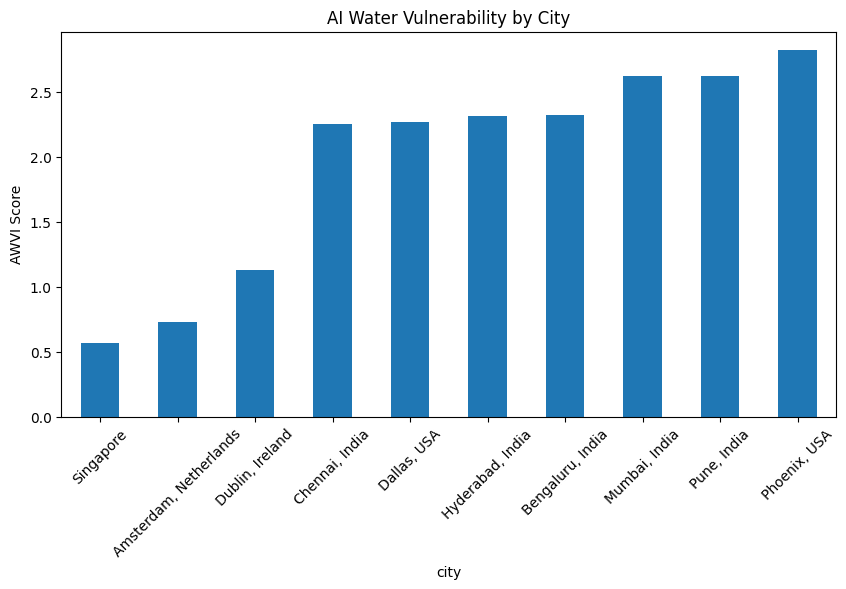

In [2]:
city_risk = (
    df.groupby("city")
    ["ai_water_vulnerability_index"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

city_risk.plot(kind="bar")

plt.title(
    "AI Water Vulnerability by City"
)

plt.ylabel("AWVI Score")
plt.xticks(rotation=45)

plt.show()

Sustainability Score Ranking

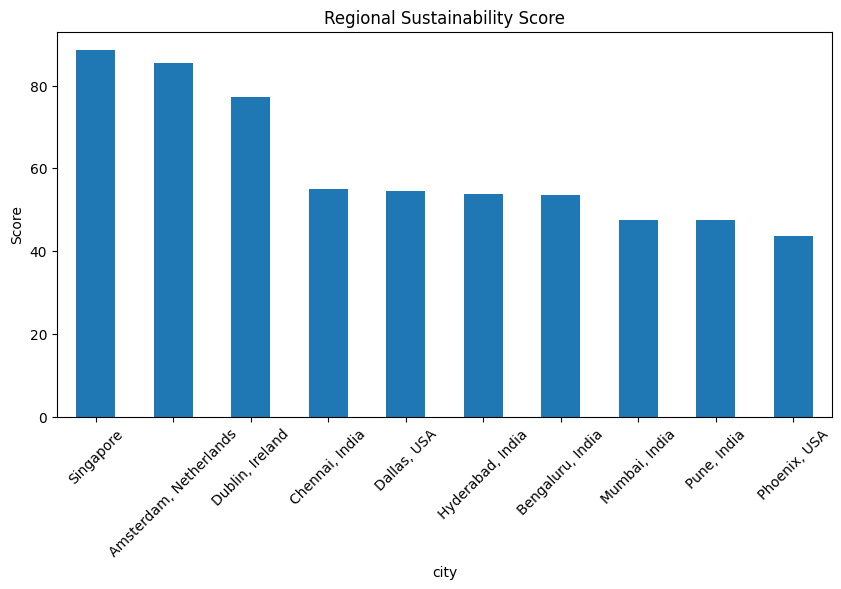

In [3]:
city_score = (
    df.groupby("city")
    ["sustainability_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

city_score.plot(kind="bar")

plt.title(
    "Regional Sustainability Score"
)

plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

Cooling Severity comparison

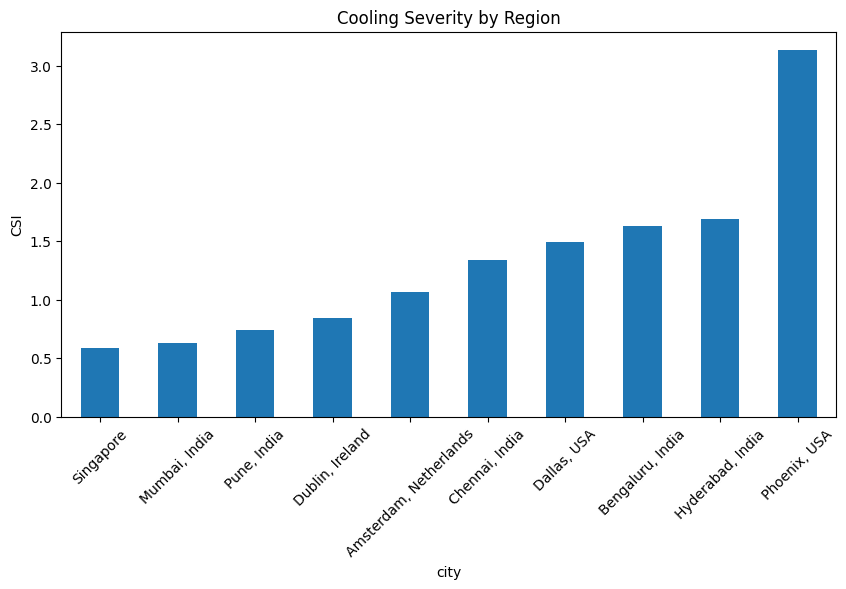

In [4]:
cooling_city = (
    df.groupby("city")
    ["cooling_severity_index"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

cooling_city.plot(kind="bar")

plt.title(
    "Cooling Severity by Region"
)

plt.ylabel("CSI")
plt.xticks(rotation=45)

plt.show()

Risk Class Count

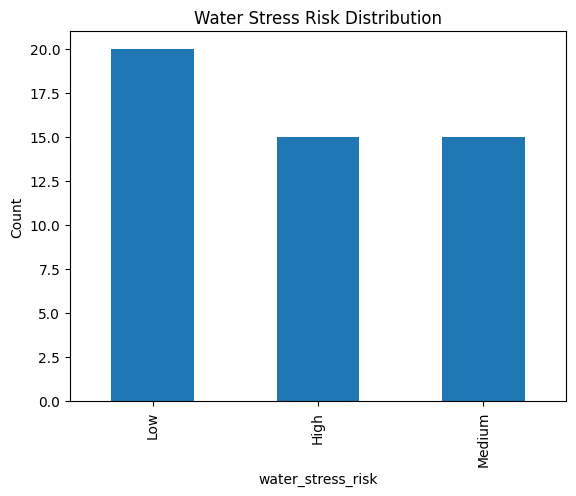

In [5]:
df["water_stress_risk"] \
.value_counts() \
.plot(kind="bar")

plt.title(
    "Water Stress Risk Distribution"
)

plt.ylabel("Count")

plt.show()

Correlation Matrix

In [6]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

print(correlation)

                                      year  avg_temperature  avg_humidity  \
year                          1.000000e+00         0.039654     -0.041731   
avg_temperature               3.965382e-02         1.000000     -0.313541   
avg_humidity                 -4.173088e-02        -0.313541      1.000000   
precipitation                 6.410135e-02         0.448253      0.440187   
baseline_water_stress        -2.902317e-14         0.493358     -0.648515   
water_depletion              -2.639167e-14         0.503300     -0.824811   
seasonal_variability         -1.834200e-14         0.199943     -0.789198   
drought_severity             -2.260494e-15         0.366446     -0.058927   
cooling_severity_index       -1.011383e-03         0.073332     -0.822895   
ai_water_vulnerability_index -2.512219e-14         0.493028     -0.725190   
sustainability_score          2.508701e-14        -0.493028      0.725190   

                              precipitation  baseline_water_stress  \
year 